# OHLC图像数据集生成器

这个notebook用于生成深度学习训练所需的OHLC图像数据集。

**功能**:
- 从月度缓存加载USDT交易对数据
- 聚合为3min, 15min, 1h三种时间框架
- 每4小时采样生成OHLC图像
- 计算未来收益率标签
- 图像按时间框架分别保存，标签按收益时间窗口分别保存

**输出格式**:
- 图像张量: (N, 1, 64, 60) - 按时间框架保存
- 标签张量: (N,) - 按收益时间窗口分别保存
- 所有文件的第i个样本完全对齐

In [1]:
import os
import sys
import torch
import pandas as pd
import numpy as np
from typing import List, Dict, Tuple, Optional
from datetime import datetime, timedelta
from pathlib import Path
import warnings
import gc
import pickle
from tqdm import tqdm
warnings.filterwarnings('ignore')

# Add project root to path
parent = Path.cwd().parent.resolve()
if str(parent) not in sys.path:
    sys.path.insert(0, str(parent))

# Import required modules
from utils.data_loader import load_usdt_symbols_from_month_cache, get_usdt_symbols
from figure_model.ohlc_preprocessor import aggregate_ohlc_data, batch_aggregate_ohlc_data
from figure_model.ohlc2fig import ohlc_to_image_without_volume, ohlc_to_image_with_volume

print("导入完成")

导入完成


In [2]:
# 配置参数
RETURN_HORIZONS = [1, 2, 4, 8, 12, 16, 18, 24, 30, 36, 48, 72, 96, 120, 144, 168]  # 未来收益率时间窗口(小时)
TIMEFRAMES = ['3min', '15min', '1h']  # 聚合时间框架
TIMEFRAMES_SPAN_MINUTES = {'3min': 3, '15min': 15, '1h': 60}  # 时间框架对应分钟数

WINDOW_SIZE = 20  # 每个图像的OHLC条数
IMAGE_HEIGHT = 64  # 图像高度
SAMPLE_INTERVAL_HOURS = 4  # 采样间隔(小时)

# 数据加载时间缓冲区
BEFORE_TIME_SPAN = timedelta(hours=24)  # 加载当月前24小时数据
AFTER_TIME_SPAN = timedelta(hours=168)  # 加载当月后168小时数据

# 输出目录
OUTPUT_DIR = Path('/home/craz/crypto/model_training/ohlc_img_dataset')
OUTPUT_DIR.mkdir(exist_ok=True)

# 获取USDT交易对列表
usdt_symbols = get_usdt_symbols()
print(f"找到 {len(usdt_symbols)} 个USDT交易对")
print(f"前10个: {usdt_symbols[:10]}")

找到 512 个USDT交易对
前10个: ['1000000BOBUSDT', '1000000MOGUSDT', '1000BONKUSDT', '1000CATUSDT', '1000CHEEMSUSDT', '1000FLOKIUSDT', '1000LUNCUSDT', '1000PEPEUSDT', '1000RATSUSDT', '1000SATSUSDT']


In [3]:
def month_iter(start_year, start_month, end_year, end_month):
    """生成月份迭代器"""
    y, m = start_year, start_month
    while (y < end_year) or (y == end_year and m <= end_month):
        yield datetime(y, m, 1).date()
        if m == 12:
            y += 1
            m = 1
        else:
            m += 1

def get_sampling_timestamps(start_time: datetime, end_time: datetime, interval_hours: int) -> List[datetime]:
    """生成采样时间戳列表"""
    timestamps = []
    current = start_time
    while current <= end_time:
        timestamps.append(current)
        current += timedelta(hours=interval_hours)
    return timestamps

def extract_ohlc_window(data: pd.DataFrame, symbol: str, end_time: datetime, 
                       window_size: int = 20) -> Optional[pd.DataFrame]:
    """提取指定符号和结束时间的OHLC窗口数据"""
    try:
        # 获取该符号的数据
        symbol_data = data.xs(symbol, level='symbol')
        
        # 找到结束时间在时间序列中的位置
        timestamps = symbol_data.index
        
        # 找到最接近end_time的时间戳
        end_idx = timestamps.get_indexer([end_time], method='nearest')[0]
        if end_idx == -1 or end_idx < window_size - 1:
            return None
        
        # 提取窗口数据
        start_idx = end_idx - window_size + 1
        window_data = symbol_data.iloc[start_idx:end_idx + 1]
        
        if len(window_data) != window_size:
            return None
            
        return window_data
        
    except Exception as e:
        return None

def calculate_future_returns(data_1h: pd.DataFrame, symbol: str, current_time: datetime,
                           horizons: List[int]) -> Optional[np.ndarray]:
    """计算未来收益率"""
    try:
        # 获取该符号的1小时数据
        symbol_data = data_1h.xs(symbol, level='symbol')
        timestamps = symbol_data.index
        
        # 找到当前时间最近的价格
        current_idx = timestamps.get_indexer([current_time], method='nearest')[0]
        if current_idx == -1:
            return None
        
        current_price = symbol_data.iloc[current_idx]['close']
        
        # 计算各个时间窗口的未来收益率
        returns = []
        for horizon_hours in horizons:
            future_time = current_time + timedelta(hours=horizon_hours)
            
            # 找到未来时间最接近的数据点
            future_candidates = timestamps[timestamps >= future_time]
            if len(future_candidates) == 0:
                return None  # 没有足够的未来数据
            
            # 使用第一个候选时间戳（最接近的未来时间点）
            future_timestamp = future_candidates[0]
            future_idx = timestamps.get_loc(future_timestamp)  # 使用get_loc代替get_indexer
            
            future_price = symbol_data.iloc[future_idx]['close']
            return_pct = (future_price - current_price) / current_price
            returns.append(return_pct)
        
        return np.array(returns, dtype=np.float32)
        
    except Exception as e:
        print(f"计算未来收益率时出错: {e}")
        return None

def generate_ohlc_image(window_data: pd.DataFrame, height: int = 64, 
                       include_volume: bool = False) -> np.ndarray:
    """将OHLC数据转换为图像"""
    if include_volume:
        return ohlc_to_image_with_volume(window_data, window=len(window_data), height=height)
    else:
        return ohlc_to_image_without_volume(window_data, window=len(window_data), height=height)

print("辅助函数定义完成")

辅助函数定义完成


In [4]:
def process_single_month(year: int, month: int, 
                        symbols_limit: Optional[int] = None,
                        samples_per_symbol_limit: Optional[int] = None) -> Dict[str, Dict]:
    """处理单个月份的数据生成 - 确保所有时间框架数据对齐"""
    
    print(f"\n{'='*60}")
    print(f"处理 {year:04d}-{month:02d}")
    print(f"{'='*60}")
    
    # 计算月份日期范围
    import calendar
    first_day = datetime(year, month, 1).date()
    last_day_num = calendar.monthrange(year, month)[1]
    last_day = datetime(year, month, last_day_num).date()
    
    month_start = datetime.combine(first_day, datetime.min.time())
    month_end = datetime.combine(last_day, datetime.max.time())
    
    print(f"月份范围: {month_start} 到 {month_end}")
    
    # 加载数据(包含前后缓冲区用于计算收益率)
    data_start = month_start - BEFORE_TIME_SPAN
    data_end = month_end + AFTER_TIME_SPAN
    
    print(f"加载数据范围: {data_start} 到 {data_end}")
    
    try:
        # 加载月度数据
        month_data = load_usdt_symbols_from_month_cache(
            start_date=data_start.strftime('%Y-%m-%d'),
            end_date=data_end.strftime('%Y-%m-%d')
        )
        
        if month_data is None or len(month_data) == 0:
            print("❌ 未能加载到数据")
            return {}
            
        print(f"✅ 成功加载数据: {len(month_data):,} 条记录")
        
        # 获取可用的交易对列表（在释放数据前）
        available_symbols = month_data.index.get_level_values('symbol').unique().tolist()
        if symbols_limit:
            available_symbols = available_symbols[:symbols_limit]
        print(f"处理 {len(available_symbols)} 个交易对")
        
        # 聚合到不同时间框架
        print("聚合数据到不同时间框架...")
        aggregated_data = batch_aggregate_ohlc_data(month_data, timeframes=TIMEFRAMES)
        
        # 释放原始数据内存
        del month_data
        gc.collect()
        
        if not aggregated_data:
            print("❌ 数据聚合失败")
            return {}
            
        print(f"✅ 聚合完成，包含时间框架: {list(aggregated_data.keys())}")
        
        # 确保有1小时数据用于计算收益率
        if '1h' not in aggregated_data:
            print("❌ 缺少1小时数据，无法计算收益率")
            return {}
        
        data_1h = aggregated_data['1h']
        
        # 生成采样时间戳
        sampling_timestamps = get_sampling_timestamps(
            month_start, month_end, SAMPLE_INTERVAL_HOURS
        )
        print(f"生成 {len(sampling_timestamps)} 个采样时间点")
        
        # 新的对齐处理方式：先确定有效样本，然后为所有时间框架生成相同的样本
        print(f"\n🎯 开始数据对齐处理...")
        
        # Step 1: 确定有效的 (symbol, timestamp) 组合
        valid_samples = []
        
        print("第一步：确定所有时间框架都有效的样本组合...")
        for symbol in available_symbols:
            symbol_samples = 0
            
            for timestamp in sampling_timestamps:
                if samples_per_symbol_limit and symbol_samples >= samples_per_symbol_limit:
                    break
                
                # 检查所有时间框架是否都有有效数据
                all_timeframes_valid = True
                
                # 检查是否可以计算未来收益率
                future_returns = calculate_future_returns(data_1h, symbol, timestamp, RETURN_HORIZONS)
                if future_returns is None:
                    continue
                
                # 检查每个时间框架是否都有有效的OHLC窗口
                for timeframe in TIMEFRAMES:
                    if timeframe not in aggregated_data:
                        all_timeframes_valid = False
                        break
                    
                    window_data = extract_ohlc_window(
                        aggregated_data[timeframe], symbol, timestamp, WINDOW_SIZE
                    )
                    if window_data is None:
                        all_timeframes_valid = False
                        break
                
                # 只有当所有时间框架都有效时，才添加到有效样本列表
                if all_timeframes_valid:
                    valid_samples.append({
                        'symbol': symbol,
                        'timestamp': timestamp,
                        'future_returns': future_returns
                    })
                    symbol_samples += 1
        
        print(f"✅ 找到 {len(valid_samples)} 个对齐的有效样本")
        
        if len(valid_samples) == 0:
            print("❌ 没有找到有效的对齐样本")
            return {}
        
        # Step 2: 为所有时间框架生成相同的图像样本
        results = {'images': {}, 'labels': None, 'metadata': None}
        
        # 提取统一的标签和元数据（所有时间框架共享）
        labels_array = np.array([sample['future_returns'] for sample in valid_samples])
        shared_metadata = [{
            'symbol': sample['symbol'],
            'timestamp': sample['timestamp'],
            'year': year,
            'month': month
        } for sample in valid_samples]
        
        results['labels'] = labels_array
        results['metadata'] = shared_metadata
        
        print(f"✅ 统一标签数组形状: {labels_array.shape}")
        
        # 为每个时间框架生成图像
        for timeframe in TIMEFRAMES:
            print(f"\n--- 处理时间框架: {timeframe} ---")
            
            tf_data = aggregated_data[timeframe]
            images = []
            successful_samples = 0
            
            # 使用相同的有效样本列表
            for sample_info in tqdm(valid_samples, desc=f"生成{timeframe}图像"):
                symbol = sample_info['symbol']
                timestamp = sample_info['timestamp']
                
                # 提取OHLC窗口数据（我们已经验证过这是有效的）
                window_data = extract_ohlc_window(tf_data, symbol, timestamp, WINDOW_SIZE)
                
                # 生成图像
                try:
                    image = generate_ohlc_image(
                        window_data, IMAGE_HEIGHT, include_volume=False
                    )
                    
                    images.append(image)
                    successful_samples += 1
                    
                except Exception as e:
                    print(f"图像生成错误 {symbol} @ {timestamp}: {e}")
                    # 注意：这里不应该发生错误，因为我们已经验证过数据有效性
                    continue
            
            print(f"✅ {timeframe}: {successful_samples}/{len(valid_samples)} 个样本成功生成")
            
            if len(images) > 0:
                # 转换为张量
                try:
                    images_tensor = torch.from_numpy(np.stack(images)).unsqueeze(1).float()  # (N, 1, H, W)
                    
                    print(f"张量形状 - 图像: {images_tensor.shape}")
                    
                    results['images'][timeframe] = {
                        'images': images_tensor,
                        'config': {
                            'year': year,
                            'month': month,
                            'timeframe': timeframe,
                            'window_size': WINDOW_SIZE,
                            'image_height': IMAGE_HEIGHT,
                            'sample_interval_hours': SAMPLE_INTERVAL_HOURS,
                            'return_horizons': RETURN_HORIZONS,
                            'num_samples': len(images)
                        }
                    }
                except ImportError as e:
                    print(f"⚠️ PyTorch未安装，使用NumPy保存: {e}")
                    # 使用NumPy数组作为备选
                    images_array = np.stack(images)[:, np.newaxis, :, :]  # (N, 1, H, W)
                    
                    print(f"NumPy数组形状 - 图像: {images_array.shape}")
                    
                    results['images'][timeframe] = {
                        'images': images_array,
                        'config': {
                            'year': year,
                            'month': month,
                            'timeframe': timeframe,
                            'window_size': WINDOW_SIZE,
                            'image_height': IMAGE_HEIGHT,
                            'sample_interval_hours': SAMPLE_INTERVAL_HOURS,
                            'return_horizons': RETURN_HORIZONS,
                            'num_samples': len(images)
                        }
                    }
            else:
                print(f"⚠️  {timeframe}: 没有生成任何样本")
        
        # 验证所有时间框架的样本数量是否一致
        sample_counts = [len(results['images'][tf]['images']) for tf in TIMEFRAMES if tf in results['images']]
        if len(set(sample_counts)) == 1:
            print(f"\n✅ 数据对齐验证通过：所有时间框架都有 {sample_counts[0]} 个样本")
        else:
            print(f"\n⚠️ 数据对齐警告：样本数量不一致 {dict(zip(TIMEFRAMES, sample_counts))}")
        
        # 清理内存
        del aggregated_data
        gc.collect()
        
        return results
        
    except Exception as e:
        print(f"❌ 处理月份时出错: {e}")
        import traceback
        traceback.print_exc()
        return {}

def save_monthly_results(year: int, month: int, results: Dict[str, Dict]):
    """保存月度结果 - 新的保存方式"""
    if not results or 'images' not in results:
        print(f"⚠️  {year:04d}-{month:02d}: 没有数据需要保存")
        return
    
    print(f"\n保存 {year:04d}-{month:02d} 数据集...")
    
    # 1. 保存每个时间框架的图像
    for timeframe, data in results['images'].items():
        images_filename = f"images_{timeframe}_{year:04d}-{month:02d}"
        
        try:
            # 尝试使用torch保存
            if hasattr(data['images'], 'numpy'):
                torch.save({
                    'images': data['images'],
                    'metadata': results['metadata'],
                    'config': data['config']
                }, OUTPUT_DIR / f"{images_filename}.pt")
                images_filepath = OUTPUT_DIR / f"{images_filename}.pt"
            else:
                # 使用NumPy保存
                np.savez_compressed(OUTPUT_DIR / f"{images_filename}.npz",
                                  images=data['images'],
                                  metadata=results['metadata'],
                                  config=data['config'])
                images_filepath = OUTPUT_DIR / f"{images_filename}.npz"
        except:
            # 备用方案：使用NumPy
            np.savez_compressed(OUTPUT_DIR / f"{images_filename}.npz",
                              images=data['images'],
                              metadata=results['metadata'],
                              config=data['config'])
            images_filepath = OUTPUT_DIR / f"{images_filename}.npz"
        
        # 显示图像文件信息
        images_size_mb = images_filepath.stat().st_size / (1024 * 1024)
        num_samples = len(data['images'])
        print(f"  ✅ 图像文件 {timeframe}: {images_filepath.name} ({num_samples} 样本, {images_size_mb:.1f} MB)")
    
    # 2. 按收益时间窗口保存标签（每个时间窗口一个文件）
    if results['labels'] is not None:
        labels_array = results['labels']  # 形状: (N, 16)
        
        print(f"\n保存标签文件 - 按收益时间窗口分离:")
        for i, horizon_hours in enumerate(RETURN_HORIZONS):
            # 提取第i列（对应第i个时间窗口的收益率）
            horizon_labels = labels_array[:, i]  # 形状: (N,)
            
            # 转换时间窗口为天数表示（如果>=24小时）
            if horizon_hours >= 24:
                horizon_str = f"{horizon_hours//24}d"
                if horizon_hours % 24 != 0:
                    horizon_str += f"{horizon_hours%24}h"
            else:
                horizon_str = f"{horizon_hours}h"
            
            labels_filename = f"labels_{horizon_str}_{year:04d}-{month:02d}"
            
            try:
                # 尝试使用torch保存
                horizon_tensor = torch.from_numpy(horizon_labels).float()
                torch.save({
                    'labels': horizon_tensor,
                    'metadata': results['metadata'],
                    'config': {
                        'year': year,
                        'month': month,
                        'horizon_hours': horizon_hours,
                        'horizon_str': horizon_str,
                        'num_samples': len(horizon_labels)
                    }
                }, OUTPUT_DIR / f"{labels_filename}.pt")
                labels_filepath = OUTPUT_DIR / f"{labels_filename}.pt"
            except:
                # 备用方案：使用NumPy
                np.savez_compressed(OUTPUT_DIR / f"{labels_filename}.npz",
                                  labels=horizon_labels,
                                  metadata=results['metadata'],
                                  config={
                                      'year': year,
                                      'month': month,
                                      'horizon_hours': horizon_hours,
                                      'horizon_str': horizon_str,
                                      'num_samples': len(horizon_labels)
                                  })
                labels_filepath = OUTPUT_DIR / f"{labels_filename}.npz"
            
            # 显示标签文件信息
            labels_size_kb = labels_filepath.stat().st_size / 1024
            print(f"    {horizon_str}: {labels_filepath.name} ({len(horizon_labels)} 样本, {labels_size_kb:.1f} KB)")

print("主要处理函数定义完成 - 支持数据对齐和正确的标签分离保存")

主要处理函数定义完成 - 支持数据对齐和正确的标签分离保存


In [5]:
# # 测试单个月份 - 限制数据量进行快速测试
# print("开始测试数据生成...")

# # 测试参数
# TEST_YEAR = 2022
# TEST_MONTH = 5
# TEST_SYMBOLS_LIMIT = 5  # 只处理前5个交易对
# TEST_SAMPLES_LIMIT = 3  # 每个交易对最多3个样本

# print(f"测试配置: {TEST_YEAR}-{TEST_MONTH:02d}, 限制{TEST_SYMBOLS_LIMIT}个交易对, 每个最多{TEST_SAMPLES_LIMIT}个样本")

# # 处理测试月份
# test_results = process_single_month(
#     year=TEST_YEAR, 
#     month=TEST_MONTH,
#     symbols_limit=TEST_SYMBOLS_LIMIT,
#     samples_per_symbol_limit=TEST_SAMPLES_LIMIT
# )

# # 保存测试结果
# if test_results:
#     save_monthly_results(TEST_YEAR, TEST_MONTH, test_results)
    
#     print(f"\n🎉 测试完成! 生成了以下数据集:")
#     for timeframe in test_results.get('images', {}):
#         num_samples = len(test_results['images'][timeframe]['images'])
#         img_shape = test_results['images'][timeframe]['images'].shape
#         print(f"  {timeframe}: {num_samples} 样本")
#         print(f"    图像: {img_shape}")
    
#     if test_results.get('labels') is not None:
#         labels_shape = test_results['labels'].shape
#         print(f"  统一标签: {labels_shape} - 已按收益时间窗口分别保存")
# else:
#     print("❌ 测试失败，没有生成数据")

In [6]:
# # 检查生成的文件
# print("检查输出目录:")
# output_files = list(OUTPUT_DIR.glob("*.pt")) + list(OUTPUT_DIR.glob("*.npz"))
# print(f"找到 {len(output_files)} 个数据集文件:")

# # 分类显示文件
# image_files = [f for f in output_files if 'images_' in f.name]
# label_files = [f for f in output_files if 'labels_' in f.name]

# print(f"\n📷 图像文件 ({len(image_files)} 个):")
# for file_path in sorted(image_files):
#     file_size_mb = file_path.stat().st_size / (1024 * 1024)
#     print(f"  {file_path.name}: {file_size_mb:.1f} MB")

# print(f"\n🏷️ 标签文件 ({len(label_files)} 个):")
# for file_path in sorted(label_files):
#     file_size_kb = file_path.stat().st_size / 1024
#     print(f"  {file_path.name}: {file_size_kb:.1f} KB")

# # 加载并检查第一个图像文件的内容
# if image_files:
#     print(f"\n🔍 检查文件内容: {image_files[0].name}")
#     try:
#         if image_files[0].suffix == '.pt':
#             data = torch.load(image_files[0], weights_only=False)
#         else:
#             data = np.load(image_files[0], allow_pickle=True)
            
#         print(f"  键: {list(data.keys()) if hasattr(data, 'keys') else [key for key in data.files]}")
        
#         if 'images' in data:
#             images = data['images']
#             print(f"  图像张量: {images.shape} - {images.dtype if hasattr(images, 'dtype') else type(images)}")
#             print(f"  图像像素范围: [{images.min():.3f}, {images.max():.3f}]")
            
#         if 'config' in data:
#             config = data['config']
#             if hasattr(config, 'item'):
#                 config = config.item()
#             print(f"  配置: {config}")
            
#         if 'metadata' in data:
#             metadata = data['metadata']
#             if hasattr(metadata, 'tolist'):
#                 metadata = metadata.tolist()
#             print(f"  元数据: {len(metadata)} 条")
#             if metadata:
#                 print(f"  样本元数据示例: {metadata[0]}")
                
#     except Exception as e:
#         print(f"  ❌ 文件加载失败: {e}")

# # 检查第一个标签文件
# if label_files:
#     print(f"\n🔍 检查标签文件: {label_files[0].name}")
#     try:
#         if label_files[0].suffix == '.pt':
#             data = torch.load(label_files[0], weights_only=False)
#         else:
#             data = np.load(label_files[0], allow_pickle=True)
            
#         if 'labels' in data:
#             labels = data['labels']
#             print(f"  标签张量: {labels.shape} - {labels.dtype if hasattr(labels, 'dtype') else type(labels)}")
#             print(f"  标签范围: [{labels.min():.6f}, {labels.max():.6f}]")
            
#     except Exception as e:
#         print(f"  ❌ 标签文件加载失败: {e}")

In [7]:
# 批量处理多个月份的数据 - 生产环境使用
# 注意: 这个单元格会处理大量数据，运行时间很长，请根据需要调整参数

BATCH_PROCESS = True  # 设置为True以启用批量处理
START_YEAR, START_MONTH = 2024, 2
END_YEAR, END_MONTH = 2025, 6

if BATCH_PROCESS:
    print(f"开始批量处理: {START_YEAR}-{START_MONTH:02d} 到 {END_YEAR}-{END_MONTH:02d}")
    print("⚠️  这将处理大量数据，可能需要数小时时间")
    
    successful_months = 0
    failed_months = 0
    
    for month_date in month_iter(START_YEAR, START_MONTH, END_YEAR, END_MONTH):
        year, month = month_date.year, month_date.month
        
        try:
            # 处理完整月份 (不限制交易对和样本数)
            monthly_results = process_single_month(year, month)
            
            if monthly_results:
                save_monthly_results(year, month, monthly_results)
                successful_months += 1
                print(f"✅ {year}-{month:02d} 处理成功")
            else:
                failed_months += 1
                print(f"❌ {year}-{month:02d} 处理失败")
                
        except Exception as e:
            failed_months += 1
            print(f"❌ {year}-{month:02d} 出现异常: {e}")
            continue
    
    print(f"\n批量处理完成!")
    print(f"成功: {successful_months} 个月")
    print(f"失败: {failed_months} 个月")
    
    # 最终文件统计
    final_files = list(OUTPUT_DIR.glob("*.pt")) + list(OUTPUT_DIR.glob("*.npz"))
    total_size_mb = sum(f.stat().st_size for f in final_files) / (1024 * 1024)
    print(f"\n生成文件: {len(final_files)} 个")
    print(f"总大小: {total_size_mb:.1f} MB ({total_size_mb/1024:.2f} GB)")
else:
    print("批量处理已禁用。要启用批量处理，请将 BATCH_PROCESS 设置为 True")

开始批量处理: 2024-02 到 2025-06
⚠️  这将处理大量数据，可能需要数小时时间

处理 2024-02
月份范围: 2024-02-01 00:00:00 到 2024-02-29 23:59:59.999999
加载数据范围: 2024-01-31 00:00:00 到 2024-03-07 23:59:59.999999
Found 67 monthly pickle files
Loading 3 month(s) of data...
Loaded usdt_data_2024-01.pkl: 10,534,560 rows
Loaded usdt_data_2024-02.pkl: 10,230,390 rows
Loaded usdt_data_2024-03.pkl: 11,360,159 rows
Combining monthly data...
Applying date range filtering...
✅ Loaded 13,106,759 records for 252 symbols
📅 Date range: 2024-01-31 00:00:00 to 2024-03-07 23:59:00
✅ 成功加载数据: 13,106,759 条记录
处理 252 个交易对
聚合数据到不同时间框架...

--- Processing 3min ---

--- Processing 15min ---

--- Processing 1h ---
✅ 聚合完成，包含时间框架: ['3min', '15min', '1h']
生成 174 个采样时间点

🎯 开始数据对齐处理...
第一步：确定所有时间框架都有效的样本组合...
✅ 找到 42585 个对齐的有效样本
✅ 统一标签数组形状: (42585, 16)

--- 处理时间框架: 3min ---


生成3min图像: 100%|██████████| 42585/42585 [02:46<00:00, 255.76it/s]


✅ 3min: 42585/42585 个样本成功生成
张量形状 - 图像: torch.Size([42585, 1, 64, 60])

--- 处理时间框架: 15min ---


生成15min图像: 100%|██████████| 42585/42585 [00:44<00:00, 950.55it/s] 


✅ 15min: 42585/42585 个样本成功生成
张量形状 - 图像: torch.Size([42585, 1, 64, 60])

--- 处理时间框架: 1h ---


...

✅ 3min: 84787/84787 个样本成功生成
张量形状 - 图像: torch.Size([84787, 1, 64, 60])

--- 处理时间框架: 15min ---


生成15min图像: 100%|██████████| 84787/84787 [01:48<00:00, 781.90it/s]


✅ 15min: 84787/84787 个样本成功生成
张量形状 - 图像: torch.Size([84787, 1, 64, 60])

--- 处理时间框架: 1h ---


生成1h图像: 100%|██████████| 84787/84787 [00:57<00:00, 1483.49it/s]


✅ 1h: 84787/84787 个样本成功生成
张量形状 - 图像: torch.Size([84787, 1, 64, 60])

✅ 数据对齐验证通过：所有时间框架都有 84787 个样本

保存 2025-06 数据集...
  ✅ 图像文件 3min: images_3min_2025-06.pt (84787 样本, 1244.5 MB)
  ✅ 图像文件 15min: images_15min_2025-06.pt (84787 样本, 1244.5 MB)
  ✅ 图像文件 1h: images_1h_2025-06.pt (84787 样本, 1244.5 MB)

保存标签文件 - 按收益时间窗口分离:
    1h: labels_1h_2025-06.pt (84787 样本, 7829.5 KB)
    2h: labels_2h_2025-06.pt (84787 样本, 7829.5 KB)
    4h: labels_4h_2025-06.pt (84787 样本, 7829.5 KB)
    8h: labels_8h_2025-06.pt (84787 样本, 7829.5 KB)
    12h: labels_12h_2025-06.pt (84787 样本, 7829.6 KB)
    16h: labels_16h_2025-06.pt (84787 样本, 7829.6 KB)
    18h: labels_18h_2025-06.pt (84787 样本, 7829.6 KB)
    1d: labels_1d_2025-06.pt (84787 样本, 7829.5 KB)
    1d6h: labels_1d6h_2025-06.pt (84787 样本, 7829.6 KB)
    1d12h: labels_1d12h_2025-06.pt (84787 样本, 7829.6 KB)
    2d: labels_2d_2025-06.pt (84787 样本, 7829.5 KB)
    3d: labels_3d_2025-06.pt (84787 样本, 7829.5 KB)
    4d: labels_4d_2025-06.pt (84787 样本, 7829.5 KB)
    

In [ ]:
# import torch

# img = torch.load('/home/craz/crypto/model_training/ohlc_img_dataset/images_1h_2020-02.pt', weights_only=False)

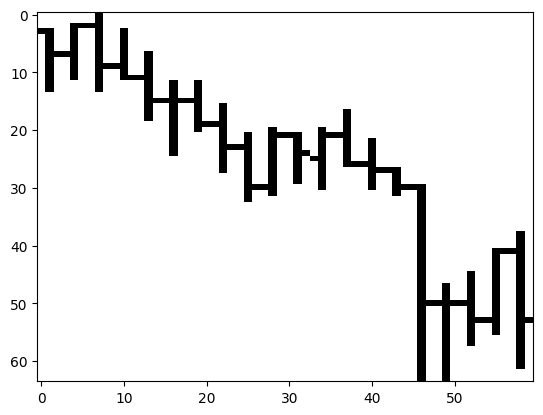

In [ ]:

# import matplotlib.pyplot as plt

# plt.imshow(img['images'][0][0], cmap='gray_r', aspect='auto')
# plt.axis('on')
# plt.show()


## 使用说明

### 新的保存结构 - 图像按时间框架分离，标签按收益时间窗口分离

本生成器现在采用新的保存方式：
1. **图像文件**: 按时间框架分别保存（3min, 15min, 1h）
2. **标签文件**: 按收益时间窗口分别保存（1h, 2h, 4h, ..., 7d）
3. **数据对齐**: 所有文件中第i个样本都来自相同的(symbol, timestamp)组合

### 生成的文件结构

每个月会生成以下文件：

**图像文件** (按时间框架):
```
images_3min_2021-01.pt    # 3分钟时间框架的图像，形状: (N, 1, 64, 60)
images_15min_2021-01.pt   # 15分钟时间框架的图像，形状: (N, 1, 64, 60)
images_1h_2021-01.pt      # 1小时时间框架的图像，形状: (N, 1, 64, 60)
```

**标签文件** (按收益时间窗口):
```
labels_1h_2021-01.pt      # 1小时后收益率，形状: (N,)
labels_2h_2021-01.pt      # 2小时后收益率，形状: (N,)
labels_4h_2021-01.pt      # 4小时后收益率，形状: (N,)
...
labels_1d_2021-01.pt      # 1天后收益率，形状: (N,)
labels_3d_2021-01.pt      # 3天后收益率，形状: (N,)
labels_7d_2021-01.pt      # 7天后收益率，形状: (N,)
```

### 文件内容格式

**图像文件**:
```python
{
    'images': torch.Tensor/numpy.ndarray,    # 形状: (N, 1, 64, 60)
    'metadata': List[Dict],                  # 样本元信息
    'config': Dict                           # 生成配置
}
```

**标签文件**:
```python
{
    'labels': torch.Tensor/numpy.ndarray,    # 形状: (N,) - 单一时间窗口的收益率
    'metadata': List[Dict],                  # 样本元信息（与图像对应）
    'config': Dict                           # 标签配置（包含时间窗口信息）
}
```

### 数据对齐保证

- 所有文件的第i个样本都来自相同的 (symbol, timestamp) 组合
- `images_3min_2021-01.pt`的第5个样本 和 `labels_1h_2021-01.pt`的第5个样本 对应同一个交易对在同一时间点的数据
- 所有文件具有完全相同的样本数量N

### 加载数据示例

**加载特定时间框架的图像和特定收益时间窗口的标签**:
```python
import torch
import numpy as np

# 加载15分钟图像和1小时收益率标签
images_data = torch.load('images_15min_2021-01.pt', weights_only=False)
labels_data = torch.load('labels_1h_2021-01.pt', weights_only=False)

images = images_data['images']      # (N, 1, 64, 60)
labels = labels_data['labels']      # (N,)
metadata = images_data['metadata']  # 样本信息

print(f"样本数量: {len(images)} 图像, {len(labels)} 标签")
print(f"数据对齐检查: {'✅对齐' if len(images) == len(labels) else '❌不对齐'}")

# 验证样本对应关系
print(f"第0个样本: {metadata[0]}")  # 应该显示相同的symbol和timestamp
```

**创建多时间框架、多收益窗口的数据集**:
```python
# 加载多个时间框架的图像
timeframes = ['3min', '15min', '1h']
images_dict = {}

for tf in timeframes:
    data = torch.load(f'images_{tf}_2021-01.pt', weights_only=False)
    images_dict[tf] = data['images']  # (N, 1, 64, 60)
    print(f"{tf}: {images_dict[tf].shape}")

# 加载多个收益时间窗口的标签  
horizons = ['1h', '4h', '1d', '7d']
labels_dict = {}

for horizon in horizons:
    data = torch.load(f'labels_{horizon}_2021-01.pt', weights_only=False)
    labels_dict[horizon] = data['labels']  # (N,)
    print(f"{horizon}: {labels_dict[horizon].shape}")

# 创建PyTorch数据加载器 - 例如：15分钟图像 + 1天收益预测
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(images_dict['15min'], labels_dict['1d'])
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

for batch_images, batch_labels in dataloader:
    print(f"批次: 图像{batch_images.shape}, 标签{batch_labels.shape}")
    break
```

### 优势说明

1. **灵活性极高**: 
   - 可以任意组合时间框架和收益窗口
   - 支持单一预测任务或多任务学习

2. **存储优化**:
   - 避免重复存储相同的标签数据
   - 标签按需加载，节省内存

3. **训练便利**:
   - 支持不同的预测任务（短期vs长期预测）
   - 可以轻松构建多时间框架的集成模型

4. **数据一致性**:
   - 严格的数据对齐保证
   - 所有文件间的样本完美对应

### 常见使用场景

1. **短期价格预测**: `images_1h_2021-01.pt` + `labels_1h_2021-01.pt`
2. **长期趋势预测**: `images_15min_2021-01.pt` + `labels_7d_2021-01.pt`  
3. **多时间框架模型**: 同时使用3min, 15min, 1h的图像
4. **多任务学习**: 同时预测1h, 1d, 7d的收益率